In [1]:
%load_ext autoreload
%autoreload 2
import os
import json
import torch
import PIL.Image as Image
import matplotlib.pyplot as plt
import torchvision.transforms as T


from mylib.plot import plot_imgs

In [2]:
# refactor modules

# TODO Speed:
# - remove all ifs, they trigger synchronization points CPU-GPU

# TODO Viewgraph:
# - clarify distances in 3d world space vs image space | THIS!

# TODO ROBUSTNESS:
# train an edge detector to find edges that are more likely to be stable across viewpoints excluding edges from vegetation, trees, water, etc
# start optimizing only on images with lots of correspondences, then extend to all?
# test more teed, find post processing right method
# optimize K only after convergence? k-t dependency
# mechanism to filter out images that are too far off | this should happen in viewgraph checking
#   - maybe based on reproj error, something like counting the percentage of inliers pairs that images are member of
# ideas:
#   - edges from semantic segmentation boundaries
#   - exlude occlusions

In [3]:
# from my datset
# with BA: vienna_mozart_satue, vienna_grillparzer, vienna_state_opera, klagenfurt_dragon, trieste_teatro_romano, munich_frauenkirche, graz_main_square

# # from TerraSky3D | Outdoor
# scene = "vienna_state_opera"
# which_data = "data_test" if scene == "graz_main_square" else "data"

# reconstruction_path = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse" 
# images_path = f"/home/mattia/Desktop/datasets/mydataset/{which_data}/{scene}/frames" 
# depths_path = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse/depth_maps"
# gt_path=f"/home/mattia/Desktop/datasets/mydataset/{which_data}/{scene}/colmap/sparse/0" 


# Load dataset paths and parameters from JSON
with open("benchmark/paths.json") as f:
    paths_cfg = json.load(f)

dataset = "mipnerf360"
scene = "treehill"
dataset_cfg = paths_cfg[dataset]

images_path = os.path.join(
    dataset_cfg["images_path"], scene, dataset_cfg["images_folder"]
)
base_path = dataset_cfg["base_path"]
reconstruction_path = os.path.join(
    base_path, scene, dataset_cfg["reconstruction_folder"]
)
depths_path = os.path.join(
    base_path,
    scene,
    dataset_cfg.get("depths_folder", dataset_cfg.get("depth_folder", "")),
)
gt_path = os.path.join(dataset_cfg["gt_path"], scene, dataset_cfg["gt_folder"])
unreliable_area_masks_path = images_path.replace(dataset_cfg["images_folder"], "depth_masks_mask2former")

print("Base path:", base_path)
print("Images path:", images_path)
print("Reconstruction path:", reconstruction_path)
print("Depths path:", depths_path)
print("GT path:", gt_path)

Base path: /home/mattia/Desktop/Repos/batchsfm/benchmark/vggt/mipnerf360
Images path: /home/mattia/Desktop/datasets/mipnerf360/treehill/images_4_150
Reconstruction path: /home/mattia/Desktop/Repos/batchsfm/benchmark/vggt/mipnerf360/treehill/sparse
Depths path: /home/mattia/Desktop/Repos/batchsfm/benchmark/vggt/mipnerf360/treehill/sparse/depth_maps
GT path: /home/mattia/Desktop/datasets/mipnerf360/treehill/sparse_150


In [4]:
from adjuster import Adjuster

adjuster = Adjuster(
    reconstruction_path = reconstruction_path,
    images_path = images_path,
    depths_path = depths_path,
    unreliable_area_masks_path=unreliable_area_masks_path,
    gt_path=gt_path,
    single_camera_per_folder=True,
    grad_k=True,
    grad_q=True,
    grad_t=True,
    grad_z=True,
    detector="teed",  # or "canny", "bdcn", "sam2"

    # # outdoor 
    lr=5e-4,
    matcher_type="frustums",  # or "exhaustive", "sequential"
    scheduler_params={"factor":0.75, "patience":3, "min_lr":1e-4},
    detector_params={"low_threshold":0.20, "high_threshold":0.25, "kernel_size":7, "sigma":2},
    viz=True,

    # indoor 
    # lr=1e-3,
    # matcher_type="frustums",  # or "exhaustive", "sequential"
    # scheduler_params={"factor":0.75, "patience":3, "min_lr":5e-6},
    # detector_params={"low_threshold":0.20, "high_threshold":0.25, "kernel_size":7, "sigma":2},

    # ## object centric
    # lr=1e-4,
    # matcher_type="sequential",  # or "exhaustive", "sequential"
    # sequential_matcher_window=10,  # only for sequential matcher
    # scheduler_params={"factor":0.8, "patience":3, "min_lr":1e-6},
    # detector_params={"low_threshold":0.20, "high_threshold":0.25, "kernel_size":7, "sigma":2},
    # scene_type="object_centric",  # or "indoor", "object_centric" (not used yet)

)


Found 141 images in /home/mattia/Desktop/datasets/mipnerf360/treehill/images_4_150


Applying unreliable area masks: 100%|██████████| 141/141 [00:00<00:00, 494.30it/s]


Max edges per image: 5,029.00
Min edges per image: 0.00
Avg edges per image: 2,812.70
Median edges per image: 3,079.00
Filtering 1,079 pairs in batches of 512


Filtering viewgraph: 100%|██████████| 3/3 [00:00<00:00,  7.20it/s]


Filtered viewgraph: 927 pairs retained


Computing distance fields: 100%|██████████| 141/141 [00:00<00:00, 1008.23it/s]



Total parameters to optimize:
  k:                4 parameters
  t:              423 parameters
  q:              564 parameters
  z:          709,089 parameters
  Total:      710,080 parameters

Using scheduler: ReduceLROnPlateau with params: {'factor': 0.75, 'patience': 3, 'min_lr': 0.0001}


dict_keys(['image', 'coords', 'scale', 'hw', 'cam_id', 'depth', 'edges_map', 'edges', 'unreliable_area_mask', 'edges_padded', 'pad_mask', 'sampled_depth', 'dt_field'])


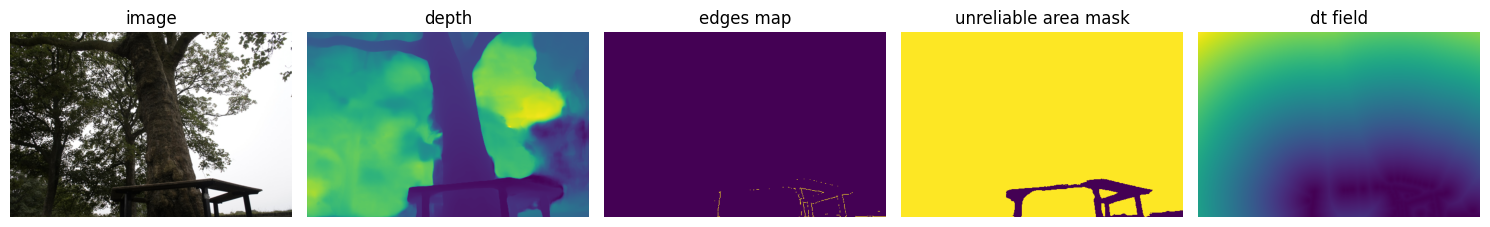

torch.Size([437, 2])


In [5]:
from mylib.plot import plot_imgs

k = sorted(list(adjuster.images.keys()))[1]
print(adjuster.images[k].keys())

plot_imgs([
    adjuster.images[k]['image'].permute(1,2,0).cpu() if 'image' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).permute(1,2,0).cpu(),
    adjuster.images[k]['depth'].cpu() if 'depth' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    adjuster.images[k]['edges_map'].cpu() if 'edges_map' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    adjuster.images[k]['unreliable_area_mask'].cpu() if 'unreliable_area_mask' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    adjuster.images[k]['dt_field'].cpu() if 'dt_field' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
], titles=["image", "depth", "edges map", "unreliable area mask", "dt field"])

print(adjuster.images[k]['edges'].cpu().shape)

In [6]:
adjuster(
    batch_size=256, 
    max_steps=-1,
    debug=True # tracks the residuals, slightly increases timing
)

Processing 927 pairs with batch size 256 (3 batches per iteration). Using 5,029 edges per image
Total points to process per iteration: 4,661,883.
Initial learning rate: 5.00e-04.
Target learning rate:  1.00e-04.



Adjusting poses and intrinsics:  10%|▉         | 99/1000 [00:40<06:09,  2.44it/s, auc5=70.9119, loss=10.0298, lr=1.00e-04]

Learning rate reached minimum threshold 1.00e-04 <= 1.00e-04. Stopping optimization.

                             Summary                              
------------------------------------------------------------------
Stage                           Time (s)        %    Per Iter
------------------------------------------------------------------
total_loading                       2.94     6.8%            
step_pre_computation                0.25     0.6%      0.0025
prepare_batched_inputs              0.20     0.5%      0.0020
forward_pass                        0.52     1.2%      0.0052
loss_computation                    1.17     2.7%      0.0117
gradient_computation                0.67     1.6%      0.0067
parameter_update                    0.10     0.2%      0.0010
logging                            37.62    86.5%      0.3762
total_optimization                 40.57    93.2%            
------------------------------------------------------------------
Total                     

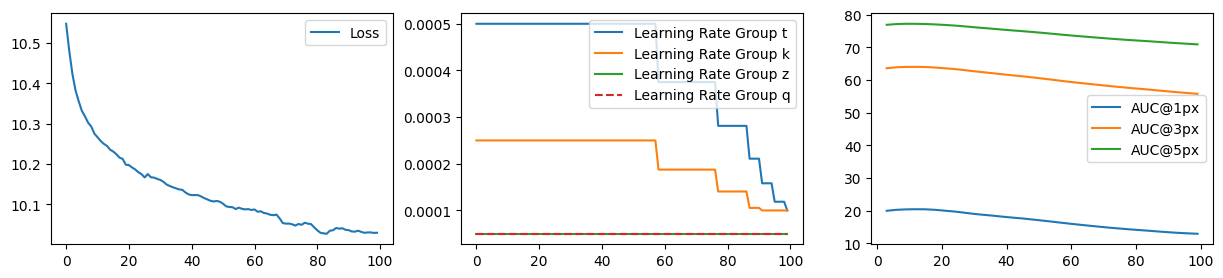

In [7]:
from matplotlib import pyplot as plt

# plot loss and lr side by side
plt.figure(figsize=(15,3))
plt.subplot(1, 3, 1)
plt.plot(adjuster.loss_list, label='Loss')
plt.legend()
plt.subplot(1, 3, 2)
for group, label in zip(adjuster.lr_list, ["t", "k", "z", "q"]):
    linestyle = '-' if label != "q" else '--'
    plt.plot(adjuster.lr_list[group], label=f'Learning Rate Group {label}', linestyle=linestyle)
plt.legend()
plt.subplot(1, 3, 3)
for th in adjuster.auc_th:
    plt.plot(adjuster.auc_list["steps"], adjuster.auc_list["auc"][th], label=f'AUC@{th}px')
plt.legend() if len(adjuster.auc_list) > 0 else None
plt.show()

In [8]:
opt = f"/home/mattia/Desktop/Repos/batchsfm/optimized_reconstruction_GD/{scene}"
os.makedirs(opt, exist_ok=True)

save_points = False

adjuster.to_colmap(
    opt, 
    verbose=False, 
    max_points_per_image=100_000//len(adjuster.images), 
    save_points=save_points, 
    final_dbscan_filtering=True, 
    dbscan_eps=0.075, dbscan_min_samples=5
)

Reconstruction(num_cameras=1, num_images=141, num_reg_images=141, num_points3D=0)

In [9]:
import sys
sys.path.append('/home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D')
from benchmark_pose import eval_colmap_model

thresholds = [1,3,5]
print("AUC@",thresholds)
AUC_score_max, num_images, df_initial = eval_colmap_model(reconstruction_path, gt_path, return_df=True, thrs=thresholds)
print("VGGT AUC:   ", AUC_score_max)

try:
    ba = reconstruction_path.replace("vggt", "vggt_ba")
    AUC_score_max, num_images, df_ba = eval_colmap_model(ba, gt_path, return_df=True, thrs=thresholds)
    print("VGGT+BA AUC:", AUC_score_max)
except:
    df_ba = None
    print("No BA reconstruction found.")
    
AUC_score_max, num_images, df_optim = eval_colmap_model(opt, gt_path, return_df=True, thrs=thresholds)
print("VGGT+EA AUC:", AUC_score_max)

AUC@ [1, 3, 5]
VGGT AUC:    [19.33867895 62.805342   76.2860147 ]
VGGT+BA AUC: [ 5.87637543 50.4965594  69.54784963]
VGGT+EA AUC: [12.88969777 55.7572856  70.91188598]


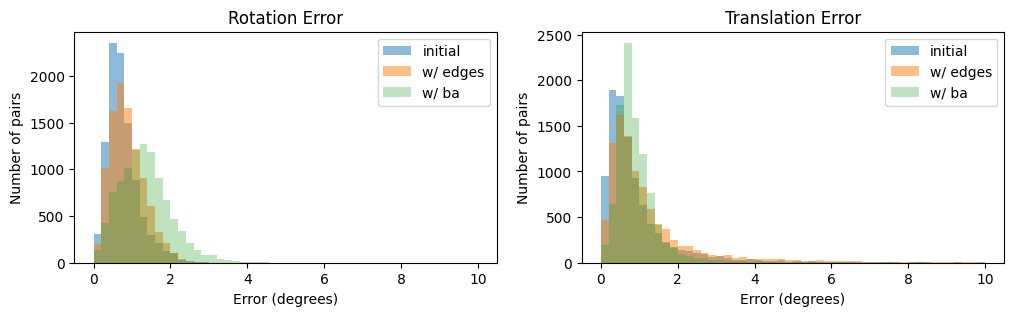

In [10]:
if True:
    bins = min(50, len(df_initial)//5)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,3))
    plt.subplot(1,2,1)
    plt.hist(df_initial.q_error, bins=bins, range=(0,10), alpha=0.5, label='initial')
    plt.hist(df_optim.q_error, bins=bins, range=(0,10), alpha=0.5, label='w/ edges')
    try:
        plt.hist(df_ba.q_error, bins=bins, range=(0,10), alpha=0.3, label='w/ ba')
    except:
        pass
    plt.title('Rotation Error')
    plt.xlabel('Error (degrees)')
    plt.ylabel('Number of pairs')
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(df_initial.t_error, bins=bins, range=(0,10), alpha=0.5, label='initial')
    plt.hist(df_optim.t_error, bins=bins, range=(0,10), alpha=0.5, label='w/ edges')
    try:
        plt.hist(df_ba.t_error, bins=bins, range=(0,10), alpha=0.3, label='w/ ba')
    except:
        pass
    plt.title('Translation Error')
    plt.xlabel('Error (degrees)')
    plt.ylabel('Number of pairs')
    plt.legend()
    plt.show()

Initial residuals (768): mean=10.547, std=4.512, min=0.000, max=20.000
Final residuals   (768): mean=10.030, std=4.536, min=0.000, max=20.000


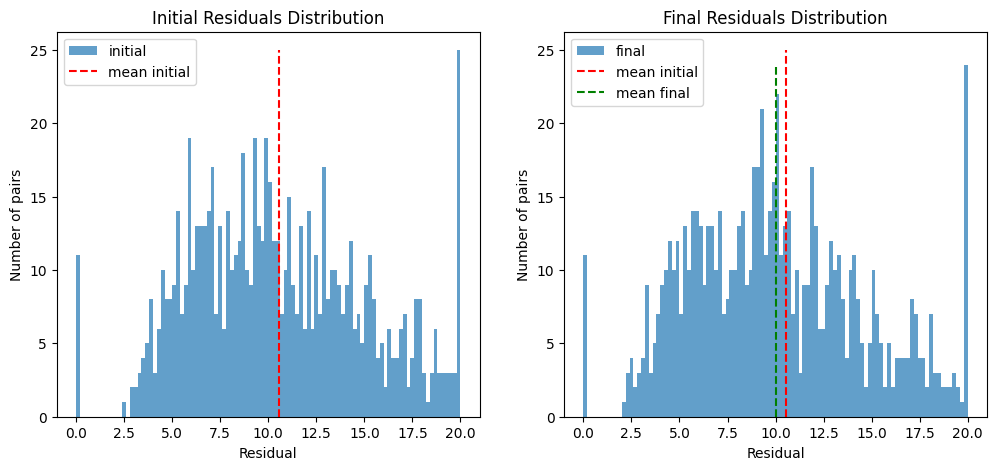

In [11]:
import torch
residuals_0 = torch.tensor(list(adjuster.residuals[0].values()))
residuals_final = torch.tensor(list(adjuster.residuals[-1].values()))

# print infos about residuals
print(f"Initial residuals ({len(residuals_0)}): mean={residuals_0.mean():.3f}, std={residuals_0.std():.3f}, min={residuals_0.min():.3f}, max={residuals_0.max():.3f}")
print(f"Final residuals   ({len(residuals_final)}): mean={residuals_final.mean():.3f}, std={residuals_final.std():.3f}, min={residuals_final.min():.3f}, max={residuals_final.max():.3f}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
out_initial = plt.hist(residuals_0, bins=100, alpha=0.7, label='initial')
# find valus for vlines
plt.vlines(residuals_0.mean(), 0, out_initial[0].max(), colors='r', linestyles='dashed', label='mean initial')
plt.title('Initial Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Number of pairs')
plt.legend()
plt.subplot(1,2,2)
out_final = plt.hist(residuals_final, bins=100, alpha=0.7, label='final')
plt.vlines(residuals_0.mean(), 0, out_initial[0].max(), colors='r', linestyles='dashed', label='mean initial')
plt.vlines(residuals_final.mean(), 0, out_final[0].max(), colors='g', linestyles='dashed', label='mean final')
plt.title('Final Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Number of pairs')
plt.legend()
plt.show()

In [12]:
adjuster.visualize_residuals(custom_viewgraph=adjuster.viewgraph[:10], output_dir=opt+"/residuals_viz")

Visualizing residuals for 10 image pairs...


Computing residuals: 100%|██████████| 10/10 [00:05<00:00,  1.84it/s]


In [13]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

## 2D Visualisation

In [ ]:
from mylib.plot import plot_imgs

viewgraph = adjuster.viewgraph
images = adjuster.images
intrinsics = adjuster.intrinsics
poses = adjuster.poses


print(len(viewgraph))
i,j = viewgraph[1]
print(i, j)

# i, j = '26/IMG_5691_frame_000058.jpg', '26/IMG_5692_frame_000001.jpg'

plot_imgs([images[i]['image'].permute(1,2,0).cpu(), images[i]['edges_map'].cpu(),images[i]['depth'].cpu(),
           images[j]['image'].permute(1,2,0).cpu(), images[j]['edges_map'].cpu(),images[j]['depth'].cpu()], 
           titles=[f"Image {i}", "Edges", "Depth", f"Image {j}", "Edges", "Depth"],
           cmap=[None, "gray","plasma"]*2, rows=2)

In [ ]:
x1,y1,x2,y2,h,w = [int(x) for x in images[i]['coords']]
img1 = images[i]['image'][:, y1:y2, x1:x2]
img2 = images[j]['image'][:, y1:y2, x1:x2]
edge1 = images[i]['edges_map'][y1:y2, x1:x2]
edge2 = images[j]['edges_map'][y1:y2, x1:x2]
Z1 = images[i]['depth'][y1:y2, x1:x2][None]
Z2 = images[j]['depth'][y1:y2, x1:x2][None]

In [ ]:
from helpers.reprojection import compute_121_reprojection
from mylib.plot import plot_imgs_and_kpts

data = {
    'P0': poses.get_projection_matrix(i),
    'P1': poses.get_projection_matrix(j),
    'K0': intrinsics.get_intrinsic_matrix(images[i]['cam_id']),
    'K1': intrinsics.get_intrinsic_matrix(images[j]['cam_id']),
    'depth0': Z1,
    'depth1': Z2
}

kpts1, kpts2, tot = compute_121_reprojection(
    data,
    img1, img2,
    verbose=False, reprojection_error=3.0, border=10, sampling_factor=10)

print(f"Consistent points: {len(kpts1):,}, {len(kpts2):,} out of {tot:,} ({100*len(kpts1)/tot:.4f}%)")
plot_imgs_and_kpts(
    img1.permute(1,2,0).cpu()*255//1,
    img2.permute(1,2,0).cpu()*255//1,
    kpts1.detach().cpu(), kpts2.detach().cpu(),
    sample_points=50_000, matches=False,
)

In [ ]:
adjuster.valid_points_per_pair[(i, j)]

In [ ]:
edge1_kpts = edge1.nonzero().flip(dims=(0,1))
edge2_kpts = edge2.nonzero().flip(dims=(0,1))

print(edge1_kpts.shape, edge2_kpts.shape)

plot_imgs_and_kpts(
    edge1[..., None].repeat(1,1,3).cpu()*255//1,
    edge2[..., None].repeat(1,1,3).cpu()*255//1,
    edge1_kpts, edge2_kpts,
    sample_points=1_000, matches=False,
) 

In [ ]:
from losses.dt_loss import sample_distance_field

dist = sample_distance_field(images[j]['dt_field'][None], images[i]['edges'] [None]).cpu()
print(f"Loss: {dist.mean():.4f}, dist length: {len(dist):,}, edges length: {len(images[i]['edges']):,}")

field = torch.zeros_like(images[j]['dt_field']).cpu()
edges = images[i]['edges'].long()
dist = dist.flatten()  # Ensure it's 1D

for idx, pt in enumerate(edges):
    field[pt[1].item(), pt[0].item()] = dist[idx].item()

plt.figure(figsize=(16,10))
plt.imshow(field, cmap="magma")
plt.show()

In [ ]:
.

## (Non working) 3D Visualization

In [ ]:
import torch
import numpy as np
import plotly.graph_objects as go
import pycolmap
from pytorch3d.renderer import SfMPerspectiveCameras
from pytorch3d.structures import Pointclouds
from pytorch3d.transforms import quaternion_to_matrix

# --- 1. Setup Device ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. Helper Functions ---

def get_camera_wireframe_tensor(scale: float = 0.3):
    """
    Returns a wireframe of a camera frustum.
    """
    # Vertex definitions for a simple frustum
    # PyTorch3D / OpenGL convention: +Z is forward, +Y is up, +X is left
    a = 0.5 * torch.tensor([-2, 1.5, 4])
    up1 = 0.5 * torch.tensor([0, 1.5, 4])
    up2 = 0.5 * torch.tensor([0, 2, 4])
    b = 0.5 * torch.tensor([2, 1.5, 4])
    c = 0.5 * torch.tensor([-2, -1.5, 4])
    d = 0.5 * torch.tensor([2, -1.5, 4])
    C = torch.zeros(3) # Camera Center
    F = torch.tensor([0, 0, 3]) # Forward direction tip
    
    camera_points = [a, up1, up2, up1, b, d, c, a, C, b, d, C, c, C, F]
    lines = torch.stack([x.float() for x in camera_points]) * scale
    return lines

def float_color_to_css(color_list):
    rgb = [int(c * 255) for c in color_list]
    return f"rgb({rgb[0]}, {rgb[1]}, {rgb[2]})"

def qvec2rotmat(qvec):
    """
    Manual conversion from COLMAP Quaternion [w, x, y, z] to Rotation Matrix.
    """
    return np.array([
        [1 - 2 * qvec[2]**2 - 2 * qvec[3]**2,
         2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
         2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2]],
        [2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
         1 - 2 * qvec[1]**2 - 2 * qvec[3]**2,
         2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1]],
        [2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
         2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
         1 - 2 * qvec[1]**2 - 2 * qvec[2]**2]])

def load_real_colmap_data(path, device):
    """
    Loads COLMAP data using raw qvec/tvec to be robust against version changes.
    Applies strict Coordinate System conversion for PyTorch3D.
    """
    print(f"Loading COLMAP model from: {path} ...")
    
    try:
        recon = pycolmap.Reconstruction(path)
    except Exception as e:
        raise ValueError(f"Error loading path '{path}'. Ensure it's a valid COLMAP sparse folder. Details: {e}")
    
    # --- A. Process Point Cloud ---
    points3d = recon.points3D
    xyz = []
    rgb = []
    
    for p_id, point in points3d.items():
        xyz.append(point.xyz)
        rgb.append(point.color)
        
    verts = torch.tensor(np.array(xyz), dtype=torch.float32, device=device)
    features = torch.tensor(np.array(rgb), dtype=torch.float32, device=device) / 255.0
    point_cloud = Pointclouds(points=[verts], features=[features])

    # --- B. Process Cameras (Extrinsics) ---
    images = recon.images
    
    R_list = []
    T_list = []
    
    # Sort by image name for logical trajectory lines
    sorted_image_keys = sorted(images.keys(), key=lambda k: images[k].name)
    
    # Coordinate Fix:
    # COLMAP (OpenCV): +X Right, +Y Down, +Z Forward
    # PyTorch3D (NDC): +X Left,  +Y Up,   +Z Forward
    # Transform: Flip X and Y axes.
    # We apply this to the World-to-View matrix.
    coord_fix = torch.tensor([
        [ 1.0,  0.0,  0.0],
        [ 0.0,  1.0,  0.0],
        [ 0.0,  0.0,  -1.0]
    ], device=device, dtype=torch.float32)
    
    for img_id in sorted_image_keys:
        img = images[img_id]
        
        # 1. robustly get qvec and tvec (works on all pycolmap versions)
        R_np = img.cam_from_world.rotation.matrix()
        tvec = img.cam_from_world.translation
        
        # 2. Convert to rotation matrix (numpy -> torch)
        R_raw = torch.from_numpy(R_np).float().to(device)
        T_raw = torch.from_numpy(tvec).float().to(device)
        
        # 3. Apply the coordinate fix
        # New_R = Fix @ Old_R
        # New_T = Fix @ Old_T
        R_fixed = coord_fix @ R_raw
        T_fixed = coord_fix @ T_raw  # Matrix-vector multiplication
        
        R_list.append(R_fixed)
        T_list.append(T_fixed)

    if not R_list:
        raise ValueError("No images found in COLMAP data.")

    # Stack
    R = torch.stack(R_list)
    T = torch.stack(T_list)

    # Initialize PyTorch3D Cameras
    cameras = SfMPerspectiveCameras(device=device, R=R, T=T)
    
    print(f" -> Loaded {len(xyz)} points and {len(sorted_image_keys)} cameras.")
    return cameras, point_cloud

# --- 3. Main Visualization Function ---

def visualize_multi_camera_single_pointcloud(model_inputs, cam_scale=0.1):
    fig = go.Figure()
    
    for i, inp in enumerate(model_inputs):
        path = inp['path']
        label = inp['label']
        color_list = inp['color']
        css_color = float_color_to_css(color_list)
        
        # Load
        cameras, point_cloud = load_real_colmap_data(path, device)
        
        # --- A. Draw Point Cloud (First input only) ---
        if i == 0:
            print("Processing Point Cloud...")
            verts = point_cloud.points_packed().detach().cpu().numpy()
            colors = point_cloud.features_packed().detach().cpu().numpy()
            
            # Subsample
            MAX_POINTS = 30_000
            if verts.shape[0] > MAX_POINTS:
                indices = np.random.choice(verts.shape[0], MAX_POINTS, replace=False)
                verts = verts[indices]
                colors = colors[indices]
            
            colors_int = (colors * 255).astype(int)
            colors_str = [f'rgb({r},{g},{b})' for r,g,b in colors_int]
            
            fig.add_trace(go.Scatter3d(
                x=verts[:, 0].tolist(),
                y=verts[:, 1].tolist(),
                z=verts[:, 2].tolist(),
                mode='markers',
                marker=dict(size=1.5, color=colors_str),
                name="Point Cloud"
            ))

        # --- B. Draw Camera Trajectory ---
        print(f"Processing Trajectory: {label}...")
        
        # 1. Get wireframe
        cam_wireframe = get_camera_wireframe_tensor(scale=cam_scale).to(device)
        
        # 2. Transform wireframe to World Space
        # This calculates C = -R.T @ T internally to place cameras correctly
        cam_trans = cameras.get_world_to_view_transform().inverse()
        cam_wires_trans = cam_trans.transform_points(cam_wireframe).detach().cpu()
        
        # 3. Plotly formatting
        n_cams, n_lines, _ = cam_wires_trans.shape
        nan_tensor = torch.full((1, 3), float('nan'))
        
        wires_with_nans = []
        for cam_idx in range(n_cams):
            wires_with_nans.append(cam_wires_trans[cam_idx])
            wires_with_nans.append(nan_tensor)
        
        all_wires_np = torch.cat(wires_with_nans, dim=0).numpy()
        
        fig.add_trace(go.Scatter3d(
            x=all_wires_np[:, 0].tolist(),
            y=all_wires_np[:, 1].tolist(),
            z=all_wires_np[:, 2].tolist(),
            mode='lines',
            line=dict(color=css_color, width=2),
            name=f"{label} Cameras"
        ))

    fig.update_layout(
        title="Reconstruction Visualization",
        height=900,
        width=1200,
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode='data'
        )
    )
    fig.show()

In [ ]:

model_inputs = [
    {
        'path': gt_path,
        'label': 'GT',
        'color': [0.0, 1.0, 0.0] # Green: Cameras
    },
    {
        'path': reconstruction_path,
        'label': 'VGGT Output',
        'color': [1.0, 0.0, 0.0] # Red: Cameras
    },
    {
        'path': ba,
        'label': 'BA',
        'color': [0.0, 0.0, 1.0] # Blue: Cameras
    },
    {
        'path': opt,
        'label': 'EA',
        'color': [0.0, 0.0, 0.0] # Yellow: Cameras
    },
]

# Run the visualization | Not working, coordinates convetion mismatch
# visualize_multi_camera_single_pointcloud(model_inputs, cam_scale=0.25)